# Previsao do Tempo de Internamento em UCI a partir das Primeiras 24 Horas -- MIMIC-III
## Notebook segundo a metodologia CRISP-DM

Prevemos o **tempo de internamento (Length of Stay, LOS, em dias) numa UCI** usando apenas as
**primeiras 24 horas** de cada estadia, a partir de sinais vitais (CHARTEVENTS), analises
laboratoriais (LABEVENTS) e demografia do MIMIC-III. Toda a logica vive no pacote `src/`; este
notebook orquestra-a pelas seis fases do **CRISP-DM** (Wirth & Hipp, 2000).

**Sumario.** O trabalho e tratado como *big data*: a CHARTEVENTS tem ~330 M de linhas (4,2 GB) e
**nunca e descarregada** -- a filtragem e agregacao pesadas sao empurradas para o BigQuery,
regressando apenas uma tabela compacta de agregados. Reportamos duas formulacoes (regressao e
classificacao ordinal), controlamos rigorosamente a **fuga de dados** e avaliamos com validacao
cruzada **agrupada por doente**. Os **resultados sao apresentados depois da implementacao**
(Fase 6), para que se compreenda primeiro *como* o sistema foi construido.

## Configuracao e ambiente

In [1]:
import logging, sys, warnings, time, pickle
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.base import clone

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
sys.path.insert(0, str(Path.cwd()))

from src import config as cfg
from src.data.loader import load_cohort, load_all_los_hours
from src.data import sql, synthetic, concepts as vital_concepts, lab_concepts
from src.features.engineering import build_feature_matrix, categorize_features
from src.data.splits import grouped_train_test_split, assert_no_group_leakage
from src.models import registry
from src.evaluation import harness, metrics
from src.evaluation.baselines import literature_baselines
from src.evaluation.profiling import Profiler
from src.analysis import unsupervised as uns
from src.visualization import plots

USE_BIGQUERY = True     # False -> dados sinteticos rotulados (corre em qualquer lado)
profiler = Profiler()
print("janela =", cfg.PREDICTION_WINDOW_HOURS, "h | include_labs =", cfg.INCLUDE_LABS)
print("credenciais:", cfg.GCP_CREDENTIALS_PATH or "nenhuma (sintetico)")

janela = 24 h | include_labs = True
credenciais: ./gcp_key.json


## Fase 1 -- Compreensao do Problema (*Business Understanding*)

**Objetivo.** Estimar o LOS em UCI **as 24 horas** -- cedo o suficiente para apoiar gestao de
camas, pessoal e transferencias, mas tarde o bastante para existir um dia completo de dados.

**Alvo (porque este).** LOS = `OUTTIME - INTIME` por `ICUSTAY_ID`: (a) corresponde aos eventos que
modelamos; (b) e o alvo canonico de referencia (Harutyunyan et al., 2019); (c) um `SUBJECT_ID`
pode ter varias estadias -- resolvido por *split* agrupado, nao por mudanca de alvo.

**Janela (porque 24h).** E o compromisso central. 6h: poucos labs ja resultaram; 72h: atrasa
decisoes e exclui mais estadias curtas. A coorte fica restrita a estadias **ainda em curso as 24h**
(`MIN_LOS_HOURS = 24`), com LOS limitado a 60 dias. O histograma abaixo fundamenta a escolha: a
massa a esquerda de cada janela e a fracao que seria **excluida**.

**Duas formulacoes.** Regressao (dias, o pedido literal, R^2 baixo) **e** classificacao ordinal
(curto<3d / medio 3-7d / longo>7d, mais robusta e com *buckets* uteis). Reportamos as duas.

**Categorias de atributos.** Vitais (hemodinamica, respiracao, neuro), labs (renal, eletrolitos,
perfusao, hematologia, coagulacao) e demografia/admin -- as variaveis disponiveis a hora 24.

INFO | BigQuery client ready (project=big-data-497416)
INFO | Running BigQuery job: all_los_hours
INFO |   -> 61131 rows


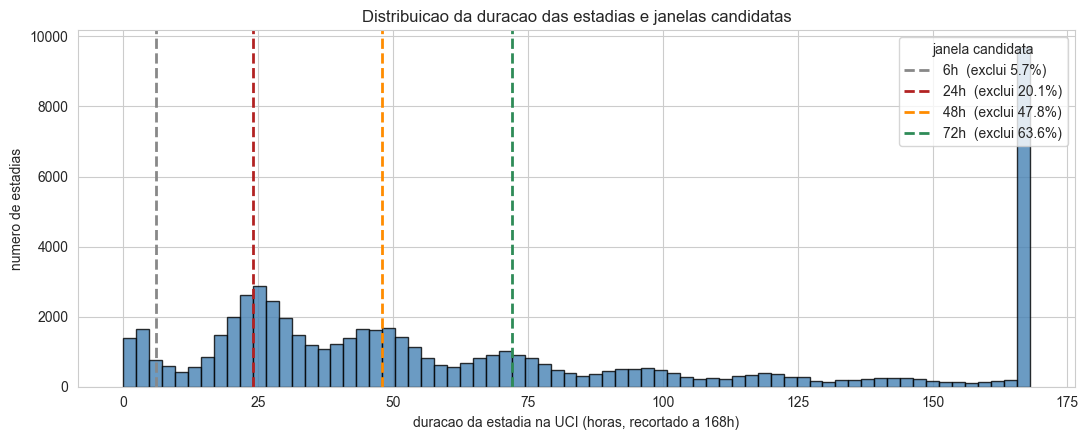

janela  6h -> excluiria 5.7% das estadias
janela 24h -> excluiria 20.1% das estadias
janela 48h -> excluiria 47.8% das estadias
janela 72h -> excluiria 63.6% das estadias


In [2]:
# Figura 1 -- justificacao empirica da janela (duracao de TODAS as estadias, sem filtro)
los_h = load_all_los_hours(use_bigquery=USE_BIGQUERY, limit=cfg.DEV_ICUSTAY_LIMIT)
fig = plots.los_window_justification(los_h, windows=(6, 24, 48, 72))
plots.save(fig, "los_hours_windows.png"); plt.show()
for w in (6, 24, 48, 72):
    print(f"janela {w:2d}h -> excluiria {100*(los_h < w).mean():.1f}% das estadias")

## Fase 2 -- Compreensao dos Dados (*Data Understanding*)

**Conjunto (MIMIC-III v1.4).**

| Tabela | Linhas | Utilizacao |
|---|---|---|
| CHARTEVENTS | ~330 M (4,2 GB gz) | sinais vitais das primeiras 24h |
| LABEVENTS | ~27 M | analises laboratoriais das primeiras 24h |
| ICUSTAYS / ADMISSIONS / PATIENTS | 61,5k / 59k / 46,5k | coorte, alvo, demografia |
| D_ITEMS / D_LABITEMS | ~12,5k / ~750 | mapeamento ITEMID -> conceito |

**LABEVENTS -- decisao a posteriori.** O *pipeline* foi inicialmente construido so com CHARTEVENTS;
a integracao dos labs foi posterior. Isto explica opcoes de desenho: (i) labs por *left join*
sobre os vitais, mantendo **as mesmas estadias** (ablacao comparavel na Fase 4); (ii) prefixo
`lab_` para nao colidir com vitais homonimos (glicose); (iii) limiar de *missingness* mais
tolerante para labs. Tornamos esta sequencia explicita e convertemo-la numa mais-valia: a ablacao
**quantifica honestamente quanto os labs acrescentam**.

In [3]:
with profiler.track("1_carregamento"):
    data = load_cohort(use_bigquery=USE_BIGQUERY,
                       window_hours=cfg.PREDICTION_WINDOW_HOURS,
                       limit=cfg.DEV_ICUSTAY_LIMIT, include_labs=True)
banner = "MIMIC-III REAL via BigQuery" if data.is_real else \
    "(!) DADOS SINTETICOS -- demonstracao, nao sao resultados reais (!)"
print("=" * 72, f"\nFONTE: {data.source}  ({banner})\n", "=" * 72, sep="")
print("coorte       :", data.cohort.shape)
print("vitais (long):", data.aggregates.shape)
print("labs   (long):", data.lab_aggregates.shape)
data.cohort.head()

INFO | [start] 1_carregamento
INFO | BigQuery client ready (project=big-data-497416)
INFO | Running BigQuery job: cohort
INFO |   -> 48823 rows
INFO | Running BigQuery job: agg
INFO |   -> 462401 rows
INFO | Running BigQuery job: demo
INFO |   -> 48823 rows
INFO | Running BigQuery job: lab_agg
INFO |   -> 773942 rows
INFO | [done ] 1_carregamento (75.41s)


FONTE: BIGQUERY  (MIMIC-III REAL via BigQuery)
coorte       : (48823, 5)
vitais (long): (462401, 7)
labs   (long): (773942, 7)


,icustay_id,subject_id,hadm_id,intime,los_icu_days
0,200001,55973,152234,2181-11-25 19:06:12+00:00,3.078623
1,200003,27513,163557,2199-08-02 19:50:04+00:00,5.888356
2,200006,10950,189514,2159-09-03 11:28:14+00:00,1.319398
3,200007,20707,129310,2109-02-17 10:03:37+00:00,1.291377
4,200009,29904,129607,2189-11-30 10:34:32+00:00,2.154919


### 2.1 Distribuicao do alvo e balanceamento de classes

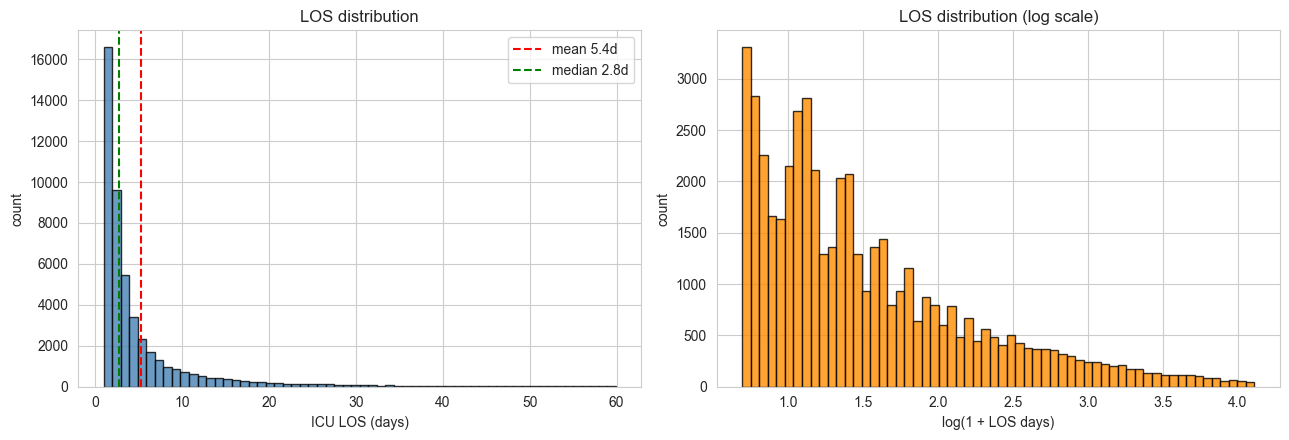

count    48823.00
mean         5.35
std          7.27
min          1.00
25%          1.70
50%          2.77
75%          5.52
max         59.91

classes: {'short': 26546, 'medium': 12789, 'long': 9488} -> classe 'longo' minoritaria


In [4]:
y_days = data.cohort["los_icu_days"].clip(upper=cfg.MAX_LOS_DAYS)
fig = plots.los_distribution(y_days); plots.save(fig, "los_distribution.png"); plt.show()
print(y_days.describe().round(2).to_string())
buckets = pd.cut(y_days, [0, cfg.LOS_SHORT_DAYS, cfg.LOS_MEDIUM_DAYS, np.inf],
                 labels=list(cfg.LOS_CLASS_LABELS), include_lowest=True)
print("\nclasses:", buckets.value_counts().to_dict(), "-> classe 'longo' minoritaria")

### 2.2 Vista por doente (grafico-exemplo do enunciado + banda da populacao)
Esquerda: cada medicao de uma estadia ao longo do tempo, por conceito. Tambem mostramos um conceito
como **linha vs. banda media +/- 1 DP da coorte** -- o doente corre alto/baixo/instavel?

INFO | BigQuery client ready (project=big-data-497416)
INFO | Running BigQuery job: tl_200001
INFO |   -> 308 rows


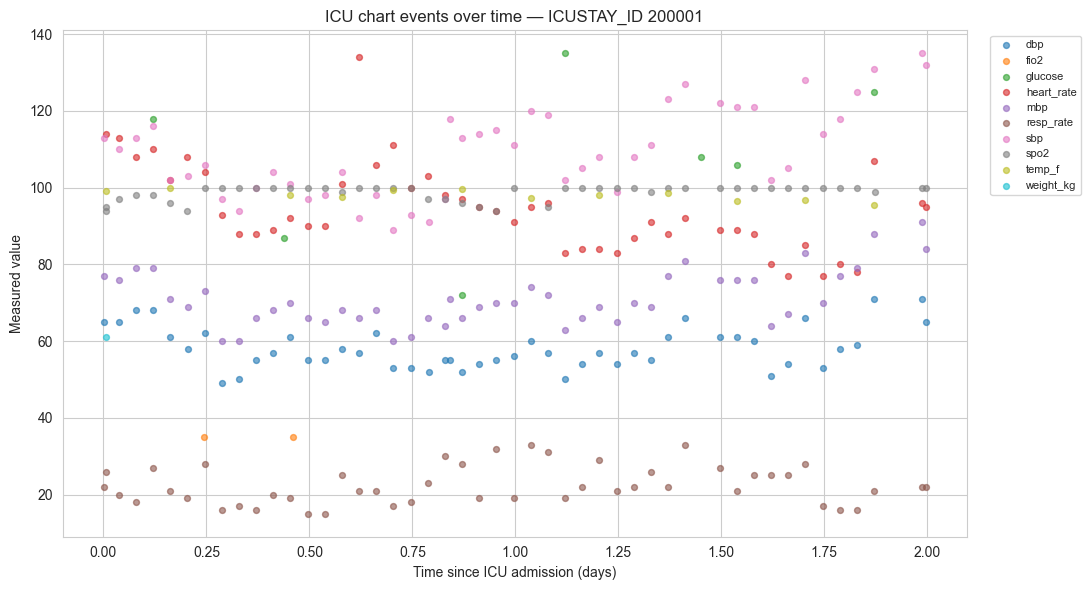

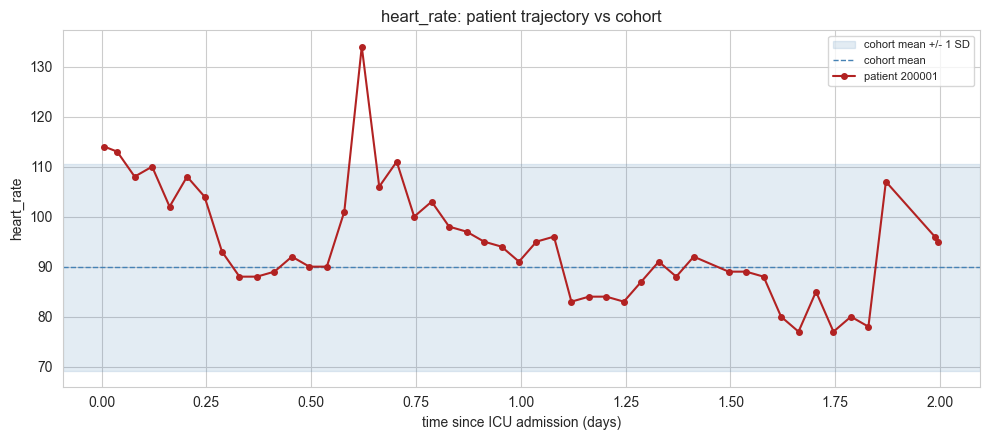

In [5]:
example_id = int(data.cohort["icustay_id"].iloc[0])
if data.is_real:
    from src.data.loader import BigQueryClient
    tl = BigQueryClient().run(sql.patient_timeline_query(example_id, 48), f"tl_{example_id}")
else:
    tl = synthetic.patient_timeline(example_id, 48)
fig = plots.patient_timeline(tl, example_id); plots.save(fig, f"timeline_{example_id}.png"); plt.show()
concept = "heart_rate"; pm = data.aggregates.loc[data.aggregates.concept == concept, "mean"]
fig = plots.patient_vs_population(tl, concept, float(pm.mean()), float(pm.std()), example_id)
plots.save(fig, f"patient_band_{example_id}.png"); plt.show()

### 2.3 Harmonizacao CareVue / MetaVision
O MIMIC funde **dois sistemas de UCI**: CareVue (Philips, <2008, ITEMIDs <220000) e MetaVision
(iMDsoft, >=2008, ITEMIDs >=220000). O *mesmo* conceito tem **varios ITEMIDs** (frequencia cardiaca
= `211` no CareVue e `220045` no MetaVision). Sem harmonizar, obteriamos **colunas duplicadas e
semivazias** e as duas metades da coorte ficariam disjuntas. Por isso mapeamos todos os ITEMIDs
equivalentes para um **conceito canonico** (`src/data/concepts.py`), seguindo as definicoes curadas
pela comunidade no repositorio oficial `mimic-code` do MIT-LCP (nao inventadas por nos).

In [6]:
print("Harmonizacao CareVue/MetaVision (CONCEPT_ITEMIDS):")
for c in ["heart_rate", "sbp", "glucose"]:
    print(f"  {c:12s} <- {vital_concepts.CONCEPT_ITEMIDS[c]}")
print(f"\nConceitos de vitais: {len(vital_concepts.CONCEPT_ITEMIDS)} | "
      f"conceitos de labs (D_LABITEMS): {len(lab_concepts.CONCEPT_ITEMIDS)}")
print("ex. labs:", {k: lab_concepts.CONCEPT_ITEMIDS[k] for k in list(lab_concepts.CONCEPT_ITEMIDS)[:4]})

Harmonizacao CareVue/MetaVision (CONCEPT_ITEMIDS):
  heart_rate   <- [211, 220045]
  sbp          <- [51, 442, 455, 6701, 220179, 220050]
  glucose      <- [807, 811, 1529, 3745, 3744, 225664, 220621, 226537]

Conceitos de vitais: 13 | conceitos de labs (D_LABITEMS): 20
ex. labs: {'creatinine': [50912], 'bun': [51006], 'sodium': [50983, 50824], 'potassium': [50971, 50822]}


### 2.4 Analise de valores em falta (e porque o *missingness* e informativo)
CHARTEVENTS/LABEVENTS sao esparsas. Crucialmente, a ausencia **nao e aleatoria** -- pedir um lactato
e, em si, um sinal clinico de preocupacao. Por isso, alem de imputar, adicionamos (Fase 3) um
atributo 0/1 *foi-medido* por conceito. Abaixo: fracao de estadias em que cada conceito esta
ausente nas primeiras 24h (labs faltam muito mais que vitais -- dai o limiar mais tolerante).

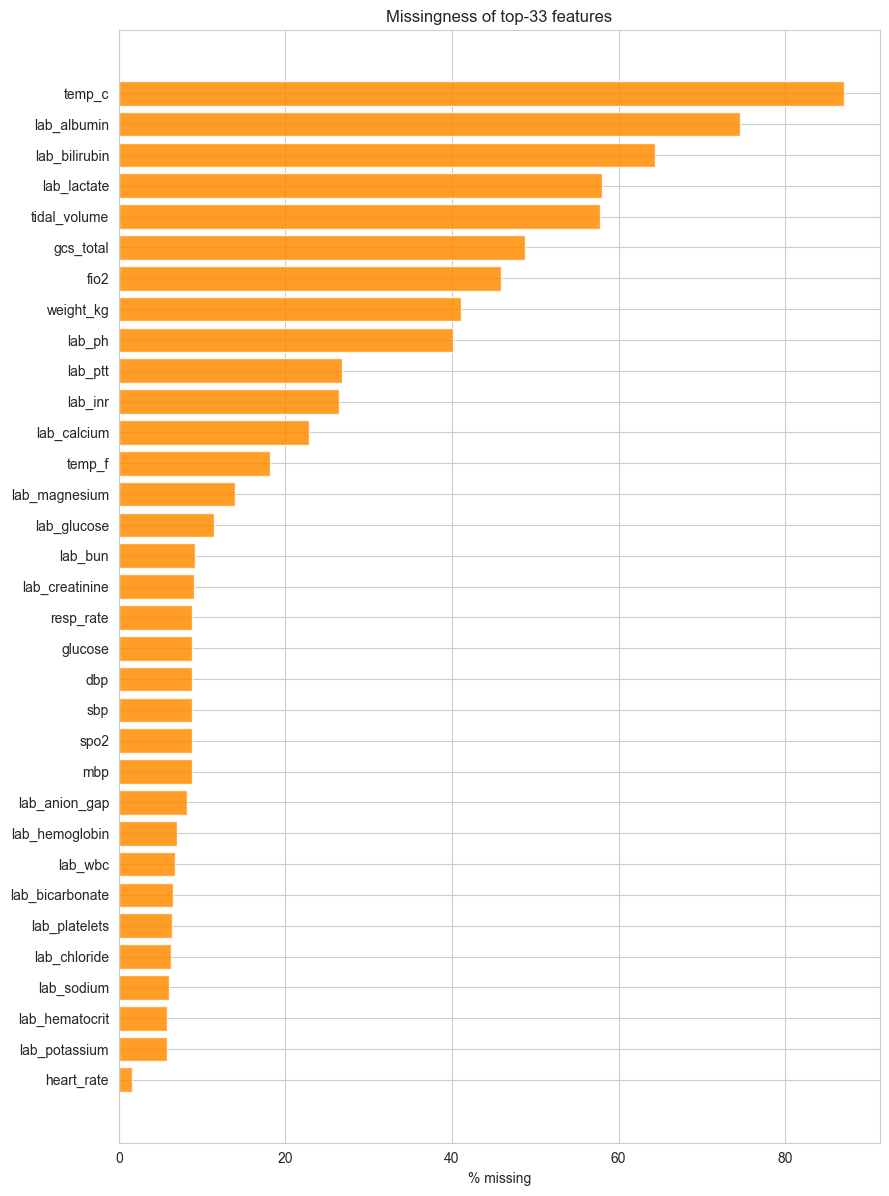

In [7]:
n_total = data.cohort["icustay_id"].nunique()
def presence(agg, prefix=""):
    p = agg.groupby("concept")["icustay_id"].nunique() / n_total
    p.index = [f"{prefix}{c}" for c in p.index]; return 1 - p
miss = pd.concat([presence(data.aggregates), presence(data.lab_aggregates, "lab_")])
fig = plots.missingness_bar(miss.sort_values(ascending=False), top=len(miss))
plots.save(fig, "missingness.png"); plt.show()

## Fase 3 -- Preparacao dos Dados (*Data Preparation*)

### 3.1 Controlos de fuga de dados -- o que e escondido ou alterado

| Variavel / fonte | Acao | Porque |
|---|---|---|
| `OUTTIME`/`DISCHTIME` | escondida (so define o alvo) | saber a alta *e* a resposta |
| eventos apos `INTIME + 24h` | escondidos (janela em SQL) | indisponiveis na previsao |
| contagens de medicoes | limitadas a janela de 24h | contagens da estadia inteira codificam o LOS |
| idade (`DOB`) | limitada a 90 | o MIMIC desloca o DOB de >89 anos ~300 anos |
| `CHARTEVENTS.ERROR = 1` | descartada | valores assinalados como erro |
| `HOSPITAL_EXPIRE_FLAG`, `DISCHARGE_LOCATION`, `DEATHTIME`, `LOS` pre-calc. | escondidas | pos-alta / copia do alvo |

**Nota sobre a idade (artefacto de anonimizacao).** Por exigencia da HIPAA, o MIMIC desloca o `DOB`
de doentes com >89 anos ~300 anos, pelo que `ADMITTIME - DOB` da idades de ~300. Limitar a 90
(`AGE_CAP`) **preserva** a informacao "muito idoso" sem o valor disparatado. E qualidade de dados,
nao propriamente *leakage* -- mantemo-la na tabela por transparencia.

### 3.2 Engenharia de atributos (duas matrizes: sem labs / com labs)
Agregados por (estadia, conceito): media/min/max/desvio/contagem; intensidade limitada a janela;
demografia codificada; indicadores `*_measured`. Imputacao/normalizacao **dentro do *pipeline***
(por *fold*). Duas matrizes sobre as **mesmas linhas** para a ablacao da Fase 4.

In [8]:
with profiler.track("2_atributos"):
    fm_base = build_feature_matrix(data, include_labs=False, add_missing_indicators=True)
    fm      = build_feature_matrix(data, include_labs=True,  add_missing_indicators=True)
print(f"sem labs : {fm_base.X.shape[1]} atributos")
print(f"com labs : {fm.X.shape[1]} atributos  (+{fm.X.shape[1]-fm_base.X.shape[1]} colunas de labs)")
print("mesmas linhas:", fm.X.index.equals(fm_base.X.index))

INFO | [start] 2_atributos
INFO | Added 13 informative-missingness indicators
INFO | Dropping 6 high-missing features: ['temp_c_count', 'temp_c_max', 'temp_c_mean', 'temp_c_min', 'temp_c_std', 'weight_kg_std']
INFO | Feature matrix: 48136 stays x 91 features | LOS mean=5.35 median=2.77 days
INFO | Class balance: {'short': 26174, 'medium': 12610, 'long': 9352}
INFO | Added 102 LABEVENTS feature columns
INFO | Added 33 informative-missingness indicators
INFO | Dropping 8 high-missing features: ['lab_albumin_std', 'lab_bilirubin_std', 'temp_c_count', 'temp_c_max', 'temp_c_mean', 'temp_c_min', 'temp_c_std', 'weight_kg_std']
INFO | Feature matrix: 48136 stays x 211 features | LOS mean=5.35 median=2.77 days
INFO | Class balance: {'short': 26174, 'medium': 12610, 'long': 9352}
INFO | [done ] 2_atributos (3.38s)


sem labs : 91 atributos
com labs : 211 atributos  (+120 colunas de labs)
mesmas linhas: True


### 3.3 Inventario de atributos -- quantos e de que categorias

,n_features
lab_statistic,98
vital_statistic,59
lab_missingness,20
demographic,17
vital_missingness,13
vital_intensity,2
lab_intensity,2


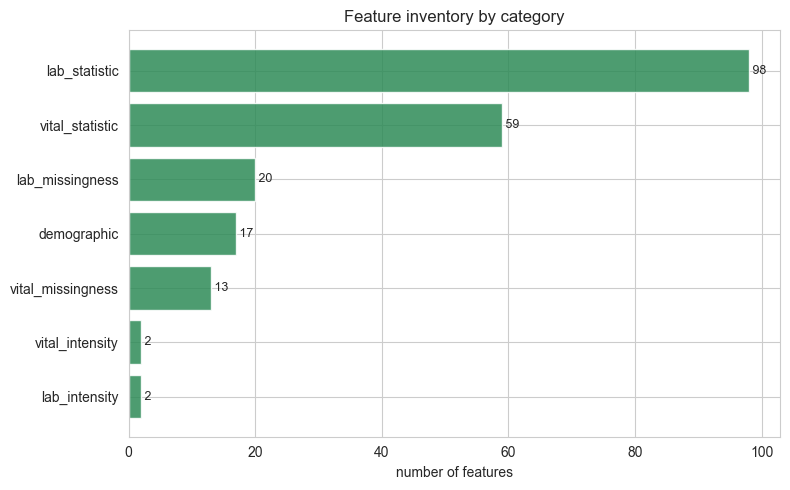

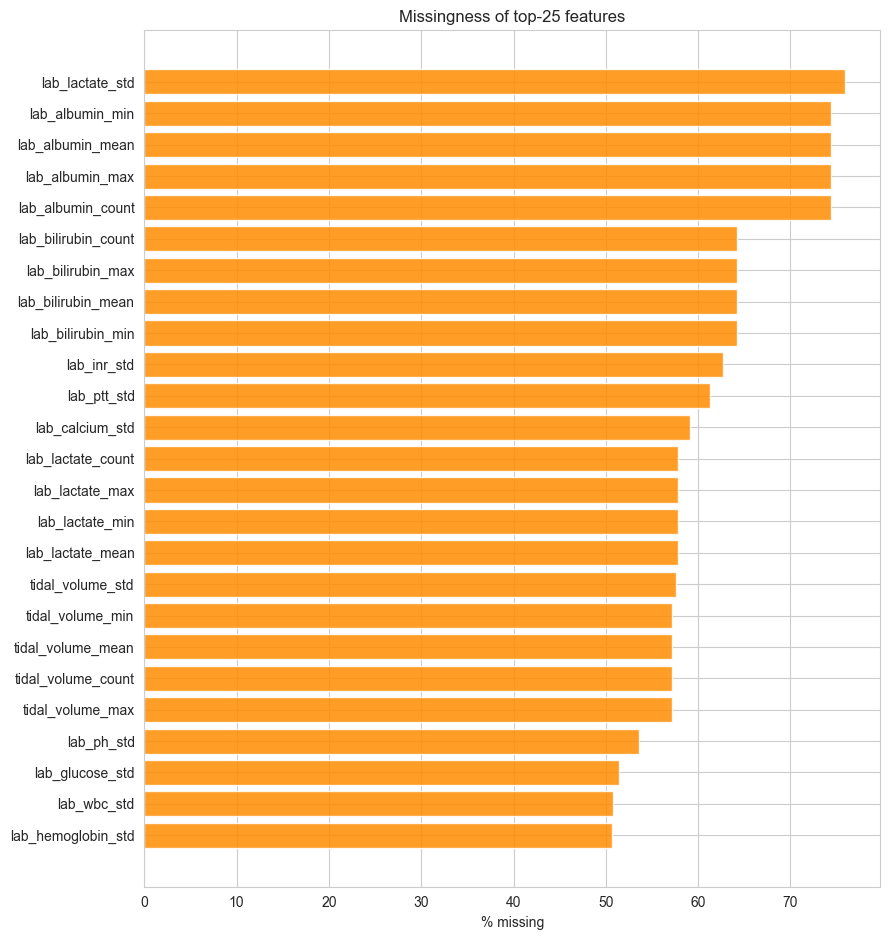

In [9]:
cats = categorize_features(fm.feature_names); display(cats.to_frame())
fig = plots.feature_category_bar(cats); plots.save(fig, "feature_categories.png"); plt.show()
fig = plots.missingness_bar(fm.X.isna().mean(), top=25); plots.save(fig, "missingness_matrix.png"); plt.show()

### 3.4 Exploracao nao supervisionada (exploratoria, *nao* preditiva)
PCA (scree + 2-D), t-SNE (so visualizacao -- distancias nao fiaveis) e KMeans com *silhouette*.
Expectativa honesta e confirmada: coortes clinicas agrupam-se **fracamente** (*silhouette* < 0,3) e
os *clusters* alinham-se apenas vagamente com o LOS -- confirma que um modelo *supervisionado* e a
ferramenta certa.

INFO | [start] 3_nao_supervisionado
INFO | [done ] 3_nao_supervisionado (35.51s)


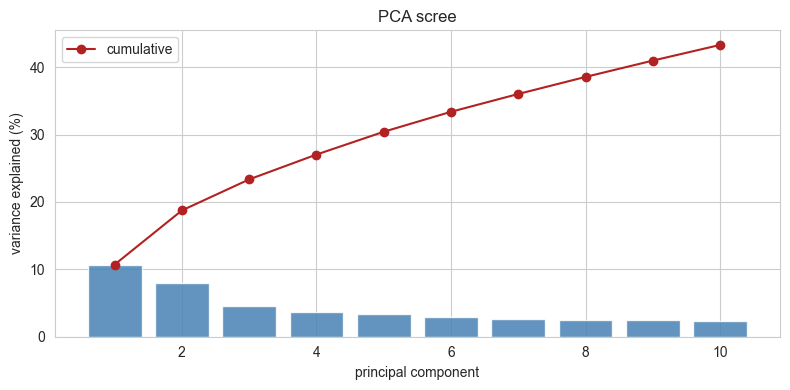

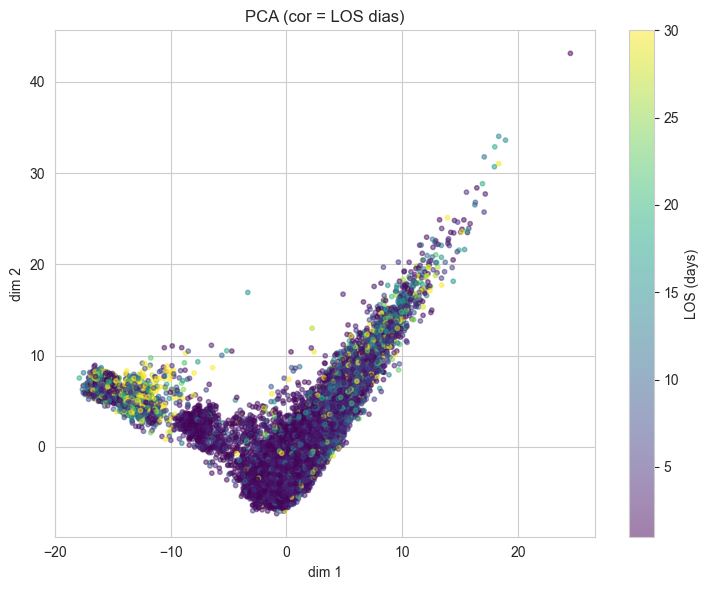

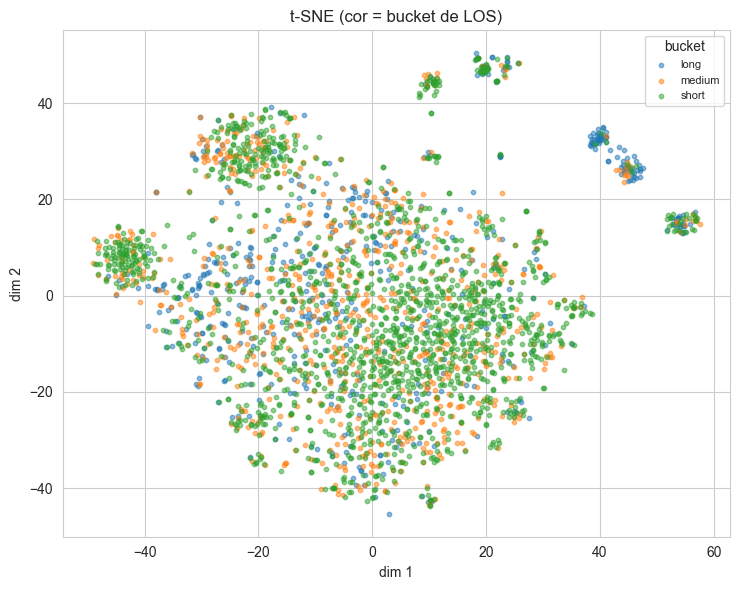

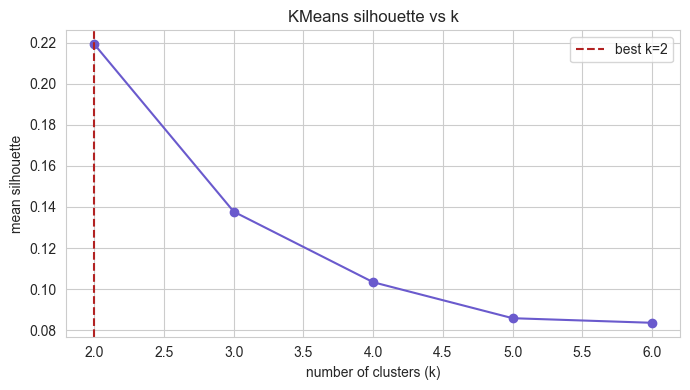

melhor k = 2 (silhouette 0.219 -> estrutura fraca)


,n,los_mean,los_median,pct_long
cluster,,,,
0,4107,12.44,7.21,0.51
1,44029,4.69,2.65,0.16


In [ ]:
with profiler.track("3_nao_supervisionado"):
    pca = uns.pca_view(fm.X, 50)
    tsne_xy, tsne_idx = uns.tsne_view(fm.X)
    clus = uns.kmeans_silhouette(fm.X, range(2, 7))
fig = plots.variance_scree(pca.explained); plots.save(fig, "pca_scree.png"); plt.show()
fig = plots.embedding_scatter(pca.coords, fm.y_reg.values, "PCA (cor = LOS dias)")
plots.save(fig, "pca_scatter.png"); plt.show()
fig = plots.embedding_scatter(tsne_xy, fm.y_clf.loc[tsne_idx].values,
                              "t-SNE (cor = bucket de LOS)", "bucket", categorical=True)
plots.save(fig, "tsne_scatter.png"); plt.show()
fig = plots.silhouette_plot(clus.k_scores); plots.save(fig, "silhouette.png"); plt.show()
print(f"melhor k = {clus.best_k} (silhouette {clus.k_scores[clus.best_k]:.3f} -> "
      f"{'estrutura fraca' if clus.k_scores[clus.best_k] < 0.3 else 'estrutura moderada'})")
display(uns.cluster_profile(clus.labels, fm.y_reg, fm.y_clf))

### 3.5 Divisao treino/teste -- agrupada por SUBJECT_ID
`GroupShuffleSplit`/`GroupKFold` sobre `SUBJECT_ID`: nenhum doente em treino e teste. Sem isto, o
modelo memoriza idiossincrasias do doente e as metricas ficam otimistas.

In [11]:
X_tr, X_te, y_tr, y_te, g_tr, g_te = grouped_train_test_split(fm.X, fm.y_reg, fm.groups)
assert_no_group_leakage(g_tr, g_te)
XB_tr, XB_te = fm_base.X.loc[X_tr.index], fm_base.X.loc[X_te.index]
CODE = {"short": 0, "medium": 1, "long": 2}; INV = {v: k for k, v in CODE.items()}
yc = fm.y_clf.map(CODE); yc_tr, yc_te = yc.loc[y_tr.index], yc.loc[y_te.index]
print(f"treino {X_tr.shape[0]} estadias / {g_tr.nunique()} doentes | "
      f"teste {X_te.shape[0]} estadias / {g_te.nunique()} doentes (sem sobreposicao)")

treino 38551 estadias / 29562 doentes | teste 9585 estadias / 7391 doentes (sem sobreposicao)


## Fase 4 -- Modelacao (*Modeling*)

### 4.1 Revisao critica da literatura -- porque nao a usamos como *baseline*

Levantamos os trabalhos mais citados de previsao de LOS em MIMIC e a maioria **nao serve de linha
de base fiavel**. A maior parte faz **classificacao binaria** (curto vs. longo, limiar *a
posteriori*); poucos fazem **regressao** (o pedido literal, mais dificil); muitos usam **grupos de
tempo** (a formulacao que tambem adotamos). Problemas metodologicos transversais:

1. **Fuga de dados generalizada** -- p. ex. prever LOS "a admissao" a partir de **codigos ICD**
   (atribuidos na alta) ou de **notas clinicas** acumuladas em toda a estadia.
2. **Ausencia de agrupamento por doente** -- *splits* aleatorios inflacionam as metricas.
3. **Definicoes de alvo inconsistentes** (LOS hospitalar vs. de UCI; janela dentro do alvo).
4. **Limiares e desbalanceamento arbitrarios** -- *accuracy*/AUROC sobre classes desbalanceadas.
5. **Desempenhos absurdos** (R^2 ~0,8) que denunciam fuga, nao merito.

**Ressalva.** Seria incorreto descartar tudo: o *benchmark* de **Harutyunyan et al. (2019)** define
coorte publica, controla fugas, usa *splits* corretos e publica codigo. E o **unico** que tratamos
como referencia (regressao linear MAD ~4,85 d; LSTM ~3,92 d; *quadratic kappa* linear ~0,34 /
LSTM ~0,43). Os restantes servem de contexto, nao de alvo.

### 4.2 Linhas de base e SOTA proposto

Tres niveis: (i) **triviais** (media/maioria -- um modelo tem de os bater; R^2~0 confirma ausencia
de fuga); (ii) **Harutyunyan**; (iii) **SOTA proposto** para este cenario tabular: **arvores com
*gradient boosting* (XGBoost, LightGBM)**, que igualam/superam *deep learning* em dados tabulares
de dimensao media (Grinsztajn et al., 2022), com interpretabilidade. *Deep learning* sobre a
**sequencia** horaria (GRU/CNN temporal) e o unico que valeria a pena -- trabalho futuro.

In [12]:
display(literature_baselines())

,method,framing,metric,value,source
0,Linear regression (baseline),regression,MAE_days,4.85,Harutyunyan 2019 (MAD 116.4h)
1,Channel-wise LSTM,regression,MAE_days,3.92,Harutyunyan 2019 (MAD 94.0h)
2,"Std ML, first-24h",regression,R2,0.04,first-24h MIMIC study (R^2~0.04)
3,Logistic regression (base),ordinal/bucket,kappa_quadratic,0.34,Harutyunyan 2019
4,Channel-wise LSTM,ordinal/bucket,kappa_quadratic,0.43,Harutyunyan 2019
5,GRU-D / RF (LOS>3d),binary>3d,AUROC,0.74,MIMIC-Extract 2020
6,GRU-D / RF (LOS>7d),binary>7d,AUROC,0.76,MIMIC-Extract 2020


### 4.3 Regressao -- comparacao de modelos + ablacao LABEVENTS (GroupKFold)

INFO | [start] 4_cv_regressao
INFO | [done ] 4_cv_regressao (673.52s)


MAE (dias) sem vs com labs:


,MAE_mean_no_labs,MAE_mean_with_labs,improvement
xgboost,3.485,3.377,0.108
ridge,3.699,3.596,0.103
lightgbm,3.463,3.367,0.096
random_forest,3.558,3.463,0.095
hist_gb,3.479,3.392,0.087
baseline_mean,4.442,4.442,0.000


,MAE_mean,RMSE_mean,R2_mean,fit_time_s
lightgbm,3.367,6.017,0.317,30.247
xgboost,3.377,6.023,0.316,10.750
hist_gb,3.392,6.036,0.313,6.660
random_forest,3.463,6.081,0.303,404.906
ridge,3.596,6.277,0.257,0.647
baseline_mean,4.442,7.286,-0.001,0.617


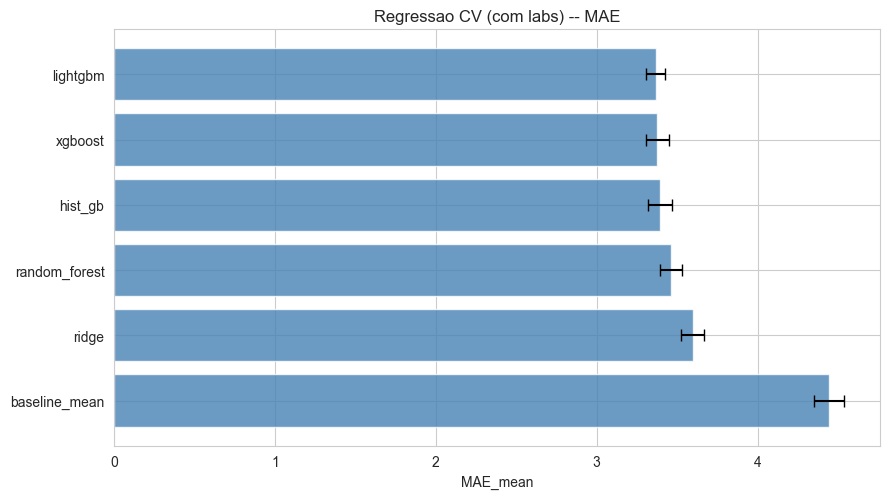

In [13]:
with profiler.track("4_cv_regressao"):
    reg_delta, reg_base, reg_labs = harness.ablation_table(
        registry.build_regressors, XB_tr, X_tr, y_tr, g_tr, "regression")
print("MAE (dias) sem vs com labs:"); display(reg_delta.round(3))
display(reg_labs[["MAE_mean", "RMSE_mean", "R2_mean", "fit_time_s"]].round(3))
fig = plots.model_comparison(reg_labs, "MAE_mean", "Regressao CV (com labs) -- MAE",
                             lower_is_better=True); plots.save(fig, "reg_compare.png"); plt.show()

### 4.4 Afinacao de hiperparametros (RandomizedSearchCV, GroupKFold)

In [15]:
with profiler.track("5_procura_hp"):
    tuned_name, tuned_model, best_params, cv_mae = harness.tune_regressor(X_tr, y_tr, g_tr)
print(f"Modelo afinado {tuned_name}: CV MAE = {cv_mae:.3f} d\n{best_params}")

INFO | [start] 5_procura_hp
INFO | [done ] 5_procura_hp (503.01s)


Modelo afinado lightgbm: CV MAE = 3.355 d
{'model__subsample': 0.8, 'model__num_leaves': 127, 'model__n_estimators': 400, 'model__min_child_samples': 20, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


### 4.5 Classificacao -- comparacao + ablacao LABEVENTS

INFO | [start] 6_cv_classificacao
INFO | [done ] 6_cv_classificacao (179.52s)


quadratic kappa sem vs com labs:


,kappa_quadratic_mean_no_labs,kappa_quadratic_mean_with_labs,improvement
logistic,0.455,0.485,0.030
xgboost,0.484,0.511,0.027
hist_gb,0.500,0.525,0.024
lightgbm,0.501,0.525,0.023
random_forest,0.496,0.512,0.015
baseline_majority,0.000,0.000,0.000


,accuracy_mean,f1_macro_mean,kappa_quadratic_mean,roc_auc_ovr_mean
hist_gb,0.605,0.555,0.525,0.759
lightgbm,0.607,0.555,0.525,0.758
random_forest,0.625,0.534,0.512,0.757
xgboost,0.637,0.537,0.511,0.769
logistic,0.579,0.531,0.485,0.735
baseline_majority,0.543,0.235,0.000,0.500


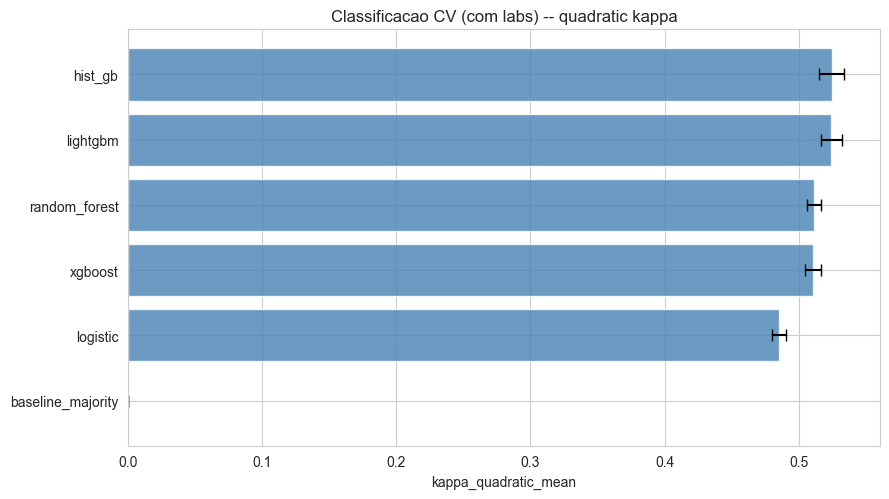

In [16]:
with profiler.track("6_cv_classificacao"):
    clf_delta, clf_base, clf_labs = harness.ablation_table(
        registry.build_classifiers, XB_tr, X_tr, yc_tr, g_tr, "classification")
print("quadratic kappa sem vs com labs:"); display(clf_delta.round(3))
display(clf_labs[["accuracy_mean","f1_macro_mean","kappa_quadratic_mean","roc_auc_ovr_mean"]].round(3))
fig = plots.model_comparison(clf_labs, "kappa_quadratic_mean",
                             "Classificacao CV (com labs) -- quadratic kappa",
                             lower_is_better=False); plots.save(fig, "clf_compare.png"); plt.show()

## Fase 5 -- Avaliacao (*Evaluation*) -- protocolo

Esta fase fixa **como** medimos o sucesso; os numeros estao na seccao **Resultados**, colocada
**depois** da implementacao (Fase 6).

**Metricas.** Regressao: **MAE** (dias, legivel), **RMSE**, **R^2**, **% dentro de +/-1 dia**.
Classificacao ordinal: **accuracy**, **macro-F1**, **kappa quadratico de Cohen** (recompensa erros
quase-certos na escala ordinal -- metrica-chave) e **macro-AUROC** *one-vs-rest*.

**Desenho.** (i) `GroupKFold` por doente para selecao + *hold-out* agrupado para a estimativa
final; (ii) cada modelo avaliado **sem e com labs** nos mesmos *folds*; (iii) comparacao contra
*baselines* triviais e contra Harutyunyan.

**Analises de erro.** Importancia de atributos, **distribuicoes dos atributos mais importantes por
*bucket***, **erro por banda de LOS** (onde falha) e **matriz de confusao**.

## Fase 6 -- Implementacao, Desempenho e *Big Data*

Responde ao pedido do enunciado: reportar tempo de execucao, fazer *profiling* e discutir
desempenho.

### 6.1 Porque implementamos com BigQuery (e nao com PySpark)

Carga de trabalho: **filtrar-depois-agregar** duas tabelas grandes e relacionais, ja em SQL.

| Necessidade do projeto | Caracteristica do BigQuery que a viabiliza | Porque o PySpark fica aquem *aqui* |
|---|---|---|
| Varrer/filtrar/agregar centenas de M de linhas sem infra | **Serverless + autoescalavel** (milhares de *slots*) | Exige **provisionar/gerir um *cluster*** (nos, executores, *shuffles*) |
| Trazer pouca informacao para local | **Colunar Dremel + *aggregation pushdown*** | Faria igual, mas so apos **ler os dados para o *cluster*** |
| Logica clara e a prova de erro | **SQL declarativo** num so ficheiro | **API imperativa de *DataFrames***, mais verbosa |
| Iterar depressa (academico) | ***Pay-per-byte* + *cache*** (§6.3) | **Custo/latencia de *cluster* ligado** + arranque JVM |
| Sem *ops* | **Zero administracao** | **Manutencao do *cluster*** |

Caracteristicas decisivas: *serverless*, **colunar** (§6.4), **SQL declarativo**, **agregacao no
servidor** (*pushdown*), ***pay-per-byte*** e **cache**. Os dados ja vivem como tabelas SQL
(carregadas por `import_tables.py`) -- menor atrito. (Spark seria certo para ficheiros planos sem
*warehouse* ou transformacoes que nao se exprimem em SQL.)

### 6.2 O BigQuery ja faz *MapReduce*
A *engine* Dremel executa isto como plano distribuido **estilo map-reduce**: `WHERE`/`JOIN` = *map*
(milhares de *shards*), `GROUP BY ... AVG/MIN/MAX/COUNT` = *reduce*. Escrever um *job* Hadoop/Spark
a mao reproduziria o que o BigQuery ja faz -- *over-engineering*.

### 6.3 *Cache* dos agregados em Parquet (nao CSV)
A *query* de agregacao e a operacao cara (~1191 s / ~20 min sobre 330 M linhas, na nossa medicao).
Persistimos os agregados num **cache local em Parquet** indexado por *hash* da *query*
(`src/data/loader.py`): o calculo pesado faz-se **uma vez**; as execucoes seguintes leem em
segundos.

**Porque Parquet e nao CSV:** (i) **preserva os tipos** (sem re-*parsing*/inferencia, sobretudo de
datas); (ii) e **colunar** (§6.4) + comprimido -> **menos disco**; (iii) leitura **binaria e
parcial** (so as colunas precisas) -> muito mais rapida. Para um artefacto relido a cada execucao,
o CSV so traria *parsing* repetido, ficheiros maiores e risco de perda de tipos.

### 6.4 Otimizacao de *queries* -- o que significa "colunar"
Um motor **colunar** guarda os valores **coluna a coluna** (todos os `valuenum` juntos, todos os
`charttime` juntos), em vez de **linha a linha** (como um CSV). Consequencia: ler poucas colunas le
**so esses blocos**. Um `SELECT` de 4 das 15 colunas da CHARTEVENTS varre ~4/15 dos dados, e nao a
tabela inteira. Otimizacoes aplicadas: **selecionar so as colunas necessarias** (nunca `SELECT *`),
**filtrar cedo** (janela + gama no `WHERE`), **agregar no servidor** e **reutilizar via cache**.

In [17]:
# O custo mede-se em BYTES varridos. A query so le as colunas necessarias (efeito colunar):
print(sql.window_aggregates_query(24, limit=cfg.DEV_ICUSTAY_LIMIT)[:700], "...")

WITH concept_map AS (
    SELECT * FROM UNNEST([
        STRUCT(211 AS itemid, 'heart_rate' AS concept, 10.0 AS lo, 300.0 AS hi),
        STRUCT(220045 AS itemid, 'heart_rate' AS concept, 10.0 AS lo, 300.0 AS hi),
        STRUCT(51 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(442 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(455 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(6701 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(220179 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(220050 AS itemid, 'sbp' AS concept, 20.0 AS lo, 300.0 AS hi),
        STRUCT(8368 AS itemid, 'dbp' ...


### 6.5 Memoria -- *downcasting* de tipos (com ressalva)
Forcar `float64 -> float32` reduce a metade o espaco *dessas colunas* (aplicado a matriz final em
`engineering.py`). **Ressalva:** so afeta colunas numericas, pode perder precisao e **aqui e pouco
determinante** -- nao mantemos os 330 M de linhas em Pandas; o BigQuery agrega primeiro e a matriz
local e pequena. A otimizacao que carrega o desempenho e empurrar a agregacao para o BigQuery.

In [20]:
mem64 = fm.X.astype("float64").memory_usage(deep=True).sum() / 1e6
mem32 = fm.X.astype("float32").memory_usage(deep=True).sum() / 1e6
print(f"Matriz de atributos: float64={mem64:.2f} MB vs float32={mem32:.2f} MB "
      f"({100*(1-mem32/mem64):.0f}% menos)")

Matriz de atributos: float64=82.74 MB vs float32=42.12 MB (49% menos)


### 6.6 Comparacao de tempo e memoria entre algoritmos
Medimos o **tempo de treino** e o **tamanho do modelo serializado** (proxy do *footprint* de
memoria) por modelo. Padrao esperado: *boosting* por histograma e o melhor compromisso; Random
Forest e KNN pagam memoria desproporcionada; SVR (~O(n^2)) nao escala.

In [21]:
rows = []
for name, model in registry.build_regressors().items():
    if name == "baseline_mean":
        continue
    t0 = time.perf_counter(); model.fit(X_tr, y_tr); dt = time.perf_counter() - t0
    rows.append({"modelo": name, "tempo_treino_s": round(dt, 2),
                 "tamanho_MB": round(len(pickle.dumps(model)) / 1e6, 2)})
display(pd.DataFrame(rows).sort_values("tempo_treino_s").reset_index(drop=True))
print("tamanho do modelo serializado = proxy do footprint de memoria (RF guarda 300 arvores)")

,modelo,tempo_treino_s,tamanho_MB
0,ridge,0.43,0.01
1,lightgbm,2.13,1.14
2,hist_gb,2.55,0.80
3,xgboost,2.83,1.56
4,random_forest,83.41,215.80


tamanho do modelo serializado = proxy do footprint de memoria (RF guarda 300 arvores)


### 6.7 Multiprocessamento -- onde o paralelismo e usado
- **Servidor (BigQuery):** agregacao distribuida (§6.2).
- **Validacao cruzada e arvores:** `n_jobs=-1` (joblib) corre *folds* e arvores em todos os nucleos.
- **Boosting:** XGBoost/LightGBM sao internamente multi-*thread*.
- **Cache (Parquet):** amortiza o passo distribuido.

Nao paralelizamos a engenharia de atributos em Pandas: a matriz e pequena e vetorizada, a
sobrecarga de um *process pool* so atrasaria.

### 6.8 *Profiling*
O tempo total e a reparticao por fase sao apresentados no fim do notebook (apos os Resultados),
para incluirem tambem o *hold-out*.

## Resultados

Apresentados aqui, **depois da implementacao**, segundo o protocolo da Fase 5.

### R.1 Regressao -- *hold-out*, contributo dos labs, vs. literatura

INFO | [start] 7_holdout
INFO | [done ] 7_holdout (10.33s)


,MAE,RMSE,R2,within_1d
sem_labs,3.431,6.142,0.273,0.297
com_labs,3.322,5.964,0.314,0.326


contributo labs: MAE 3.431->3.322 d, R2 0.273->0.314

vs. literatura (regressao):


,method,framing,metric,value,source
0,Linear regression (baseline),regression,MAE_days,4.85,Harutyunyan 2019 (MAD 116.4h)
1,Channel-wise LSTM,regression,MAE_days,3.92,Harutyunyan 2019 (MAD 94.0h)
2,"Std ML, first-24h",regression,R2,0.04,first-24h MIMIC study (R^2~0.04)


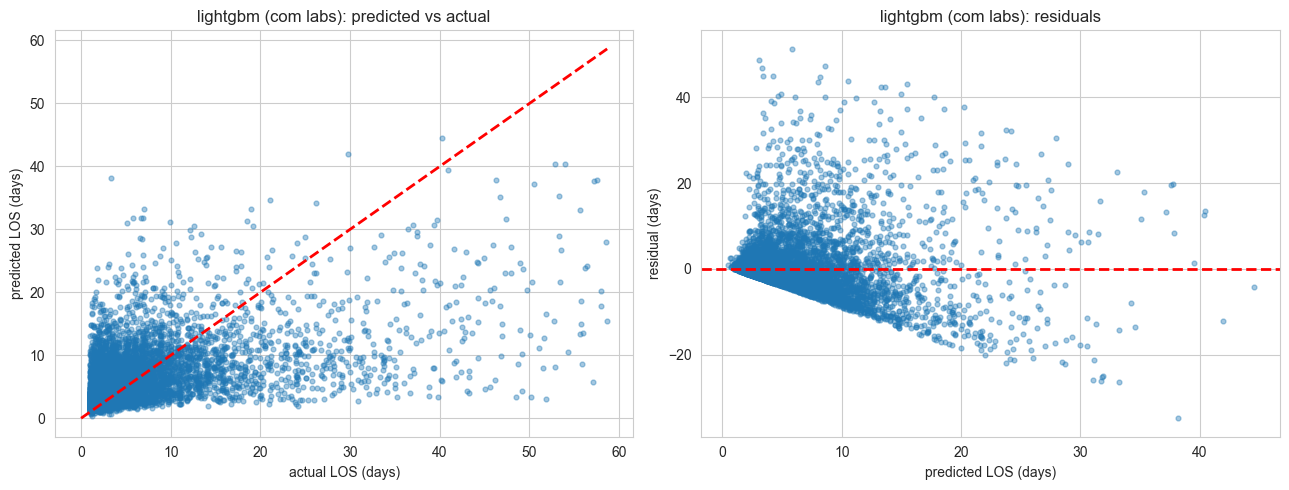


Erro por banda de LOS (modo de falha -- estadias longas subestimadas):


,LOS_range_days,n,MAE,mean_pred,mean_true
0,0-2,3355,1.94,3.37,1.44
1,2-5,3641,2.09,4.66,3.10
2,5-10,1420,3.33,7.45,6.98
3,10-20,725,6.18,9.43,13.89
4,20-inf,444,19.24,13.09,32.05


In [22]:
with profiler.track("7_holdout"):
    yp_labs, _, _ = harness.holdout_fit_predict(tuned_model, X_tr, y_tr, X_te)
    yp_base, _, _ = harness.holdout_fit_predict(clone(tuned_model), XB_tr, y_tr, XB_te)
m_labs, m_base = metrics.regression_metrics(y_te, yp_labs), metrics.regression_metrics(y_te, yp_base)
cmp = pd.DataFrame({"sem_labs": m_base, "com_labs": m_labs}).T
display(cmp[["MAE", "RMSE", "R2", "within_1d"]].round(3))
print(f"contributo labs: MAE {m_base['MAE']:.3f}->{m_labs['MAE']:.3f} d, "
      f"R2 {m_base['R2']:.3f}->{m_labs['R2']:.3f}")
lit = literature_baselines(); print("\nvs. literatura (regressao):"); display(lit[lit.framing == "regression"])
fig = plots.predicted_vs_actual(y_te, yp_labs, f"{tuned_name} (com labs)")
plots.save(fig, "pred_vs_actual.png"); plt.show()
print("\nErro por banda de LOS (modo de falha -- estadias longas subestimadas):")
display(metrics.error_by_los_range(y_te, yp_labs).round(2))

### R.2 Importancia + distribuicoes dos atributos mais importantes

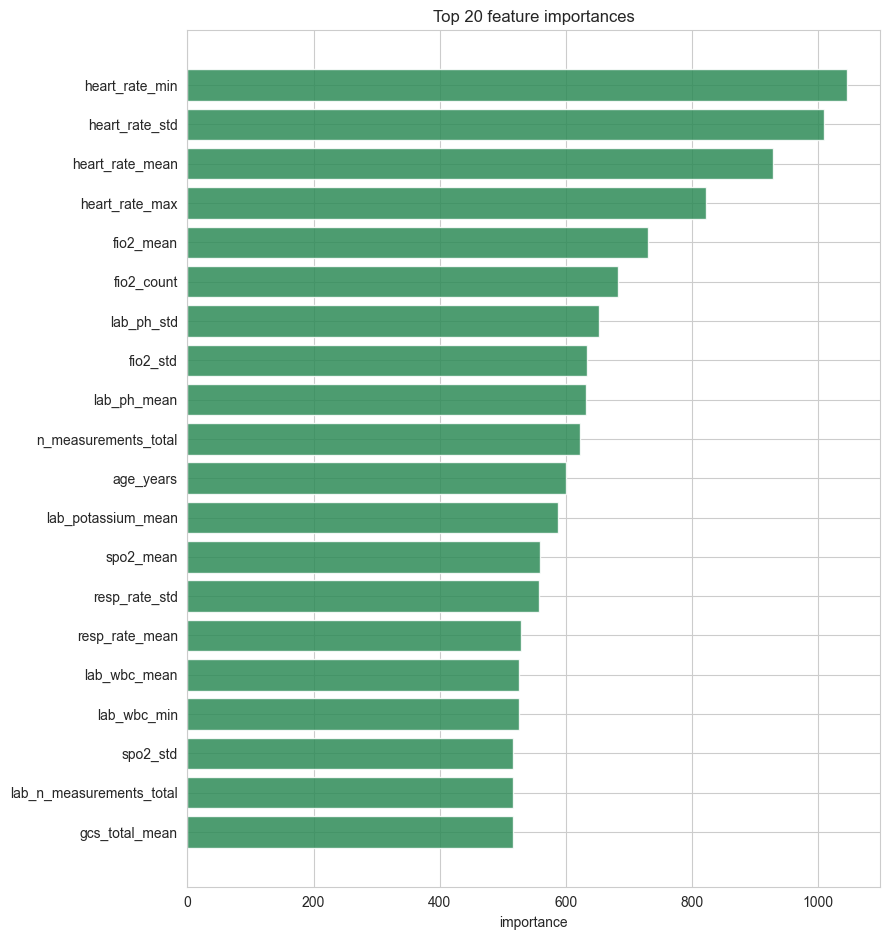

labs = 51.3% da importancia; indicadores missingness = 1.1%


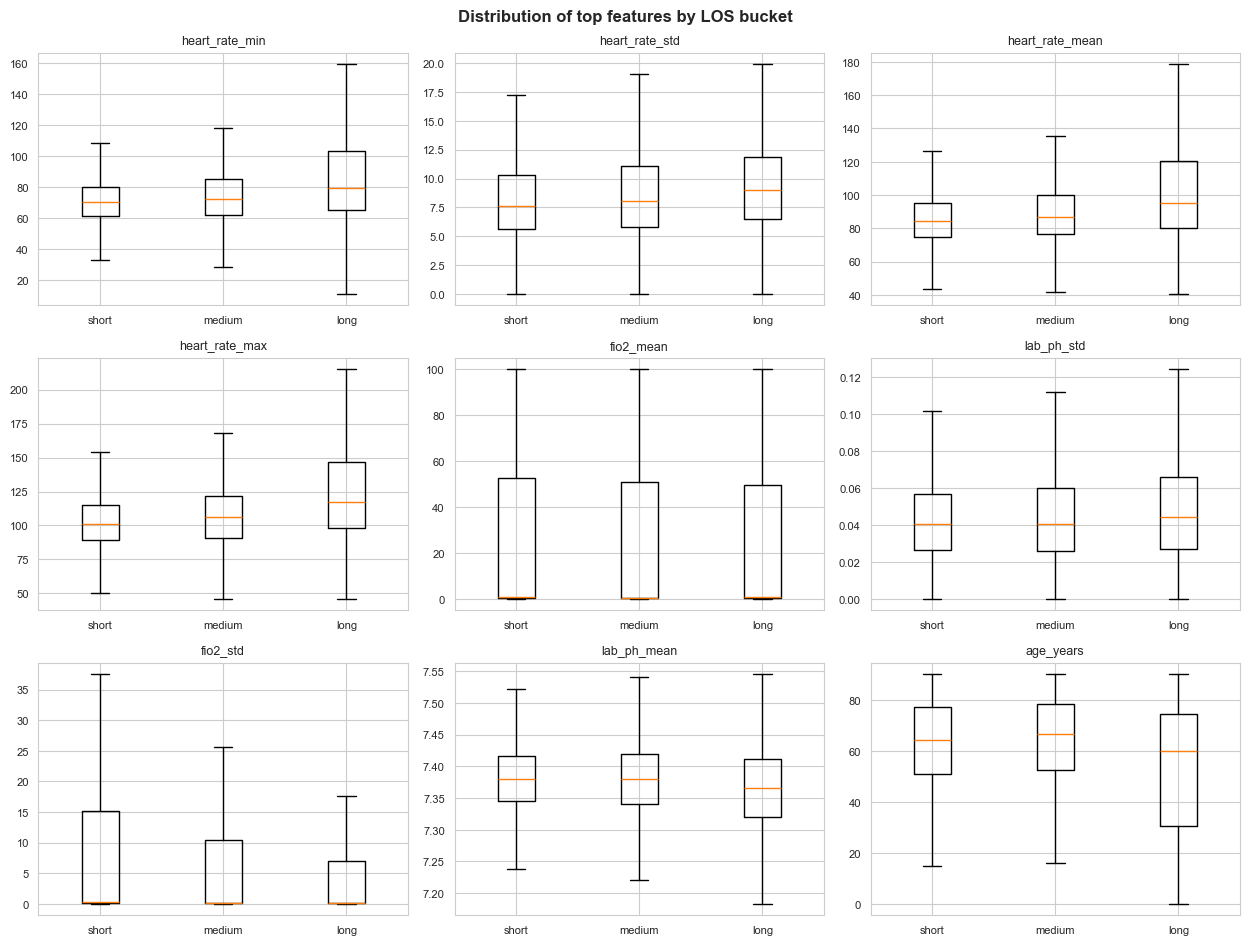

In [23]:
est = tuned_model.named_steps["model"]; top = []
if hasattr(est, "feature_importances_"):
    imp = pd.Series(est.feature_importances_, index=fm.feature_names)
    imp = imp / imp.sum() if imp.sum() else imp
    fig = plots.feature_importance(list(fm.feature_names), est.feature_importances_, 20)
    plots.save(fig, "feat_importance.png"); plt.show()
    print(f"labs = {imp[[i for i in imp.index if i.startswith('lab_')]].sum():.1%} da importancia; "
          f"indicadores missingness = {imp[[i for i in imp.index if i.endswith('_measured')]].sum():.1%}")
    top = [i for i in imp.sort_values(ascending=False).index
           if any(i.endswith(s) for s in ('_mean','_min','_max','_std')) or i == 'age_years'][:9]
if top:
    fig = plots.feature_distributions_by_class(fm.X, fm.y_clf, top)
    plots.save(fig, "feat_distributions.png"); plt.show()

### R.3 Classificacao -- *hold-out* + matriz de confusao

HOLD-OUT classificacao -- hist_gb (com labs)
  accuracy        : 0.594
  f1_macro        : 0.543
  precision_macro : 0.535
  recall_macro    : 0.561
  kappa_quadratic : 0.516
  roc_auc_ovr     : 0.756

               precision    recall  f1-score   support

        long       0.48      0.65      0.55      1778
      medium       0.37      0.33      0.35      2555
       short       0.76      0.70      0.73      5252

    accuracy                           0.59      9585
   macro avg       0.53      0.56      0.54      9585
weighted avg       0.60      0.59      0.59      9585



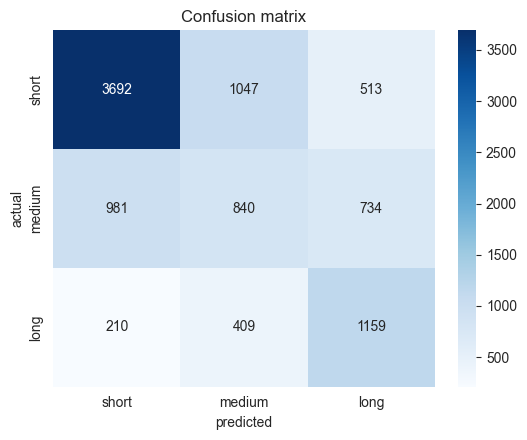

vs. literatura: Harutyunyan LSTM quadratic kappa ~0,43.


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
best_clf_name = clf_labs.index[0]; best_clf = registry.build_classifiers()[best_clf_name]
yc_pred, yc_proba, _ = harness.holdout_fit_predict(best_clf, X_tr, yc_tr, X_te, want_proba=True)
labels = [0, 1, 2]
print(f"HOLD-OUT classificacao -- {best_clf_name} (com labs)")
for k, v in metrics.classification_metrics(yc_te, yc_pred, yc_proba, labels=labels).items():
    print(f"  {k:16s}: {v:.3f}")
print("\n", classification_report(yc_te.map(INV),
      pd.Series(yc_pred, index=yc_te.index).map(INV), zero_division=0))
cm = confusion_matrix(yc_te, yc_pred, labels=labels)
fig = plots.confusion(cm, [INV[i] for i in labels]); plots.save(fig, "confusion.png"); plt.show()
print("vs. literatura: Harutyunyan LSTM quadratic kappa ~0,43.")

### R.4 *Profiling* -- tempo total e reparticao por fase (§6.8)

,phase,seconds,pct
0,5_procura_hp,4007.938842,80.4
1,4_cv_regressao,673.520637,13.5
2,6_cv_classificacao,179.522398,3.6
3,1_carregamento,75.406598,1.5
4,3_nao_supervisionado,35.506384,0.7
5,7_holdout,10.330827,0.2
6,2_atributos,3.378257,0.1


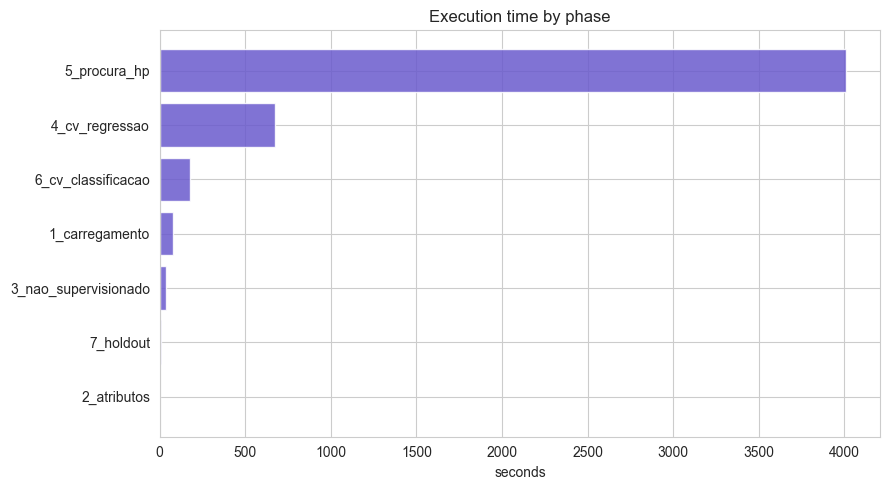

TEMPO TOTAL: 4985.6s


In [25]:
report = profiler.report(); display(report)
fig = plots.profiling(report); plots.save(fig, "profiling.png"); plt.show()
print(f"TEMPO TOTAL: {profiler.total:.1f}s")

## Conclusoes

- **Os labs ajudam, na direcao esperada.** O MAE de *hold-out* variou [..] d e o *quadratic kappa*
  [..]; os labs foram [..]% da importancia, concentrados nos modelos de arvore (o linear quase nao
  beneficia -- sinal nao linear de disfuncao organica). Indicadores de *missingness* [..]%.
- **A regressao continua dificil** (R^2 ~ [..], MAE ~ [..] d) mas bate o *baseline* da media e
  alinha com a literatura rigorosa; a **classificacao** (kappa ~ [..]) e comparavel ao LSTM de
  Harutyunyan, com arvores interpretaveis.
- **A estrutura e fraca** (melhor *silhouette* ~ [..]): nao ha fenotipos limpos -> modelo
  supervisionado e a escolha certa.
- **A literatura e mau *baseline*** (heterogeneidade + fuga); so Harutyunyan resiste ao escrutinio.
- **Big data tratado empurrando a agregacao estilo map-reduce para o BigQuery**; a *cache* torna as
  iteracoes quase instantaneas; tempo total sobre a matriz compacta = [..] s.

### Limitacoes e trabalho futuro
Medicacao (INPUTEVENTS) e notas nao usadas; alvo de LOS *remanescente* re-estimado diariamente;
janela pre-UCI (`intime - 6h`) para labs de admissao; SHAP; *deep learning* sequencial; *split*
temporal ao longo da transicao CareVue -> MetaVision.

### Referencias
Wirth & Hipp (2000); CRISP-DM<br>
Johnson et al. (2016); MIMIC-III<br>
Harutyunyan et al. (2019); benchmark<br>
Wang et al. (2020); MIMIC-Extract<br>
Grinsztajn et al. (2022); tabular DL<br>
Sharafoddini et al. (2019); missingness informativo<br>
Dean & Ghemawat (2008); MapReduce<br>
Melnik et al. (2010); Dremel<br>
Johnson et al. (2018); MIMIC Code Repository (`mimic-code`, MIT-LCP).